# Analyse_dataset - X / Truth

In [1]:
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt

In [2]:
df_trump_x = pd.read_csv("/Users/Manon/Desktop/Fac/ENC/Mémoire/Computer/Scrapping/Datasets/Scraper_X/Trump/df_trump_x_clean.csv")
df_harris_x = pd.read_csv("/Users/Manon/Desktop/Fac/ENC/Mémoire/Computer/Scrapping/Datasets/Scraper_X/Harris/df_harris_x_clean.csv")
df_trump_truth = pd.read_csv("/Users/Manon/Desktop/Fac/ENC/Mémoire/Computer/Scrapping/Datasets/Trump_Truth/Trump_truth_clean_finale.csv")

## Compte_mots - Keywords Trump

### Dataset Trump_X

#### Essai #1

In [29]:
df_trump_x = pd.read_csv("/Users/Manon/Desktop/Fac/ENC/Mémoire/Computer/Scrapping/Datasets/Scraper_X/Trump/df_trump_x_clean.csv")

In [ ]:
dico = []

for text in df_trump_x["full_text"]:
    if "immigration" in text.lower():
        dico.append(text)
    elif "migrant" in text.lower():
        dico.append(text)


In [15]:
dico

['Comrade Kamala will obliterate Social Security and Medicare by giving it away to the Millions of Illegal Immigrants who are infiltrating our Country!',
 'Comrade Kamala will obliterate Social Security and Medicare by giving it away to the Millions of Illegal Immigrants who are infiltrating our Country!',
 "COMRADE KAMALA'S MIGRANT CRIME WAVE… https://t.co/OAWVcxv6tl",
 'As President I will immediately end the migrant invasion of America. We will stop all migrant flights, end all illegal entries, terminate the Kamala phone app for smuggling illegals (CBP One App), revoke deportation immunity, suspend refugee resettlement, and return Kamala’s illegal migrants to their home countries (also known as remigration). I will save our cities and towns in Minnesota, Wisconsin, Michigan, Pennsylvania, North Carolina, and all across America. #MAGA2024!']

In [24]:
import re

mots = []
for text in dico:
    mots.extend(re.findall(r'\b\w+\b', text.lower()))

dico_counter = Counter(mots)
print(dico_counter["immigrants"])
print(dico_counter["migrant"])
print(dico_counter["immigration"])

2
3
0


#### Essai #2

In [9]:
keywords = ["immigration", "immigrant", "immigrants", "migrant", "migrants", "illegal", "illegals", "border", "aliens", "alien"]

keyword_trump_x = Counter()

for text in df_trump_x["full_text"]:
    mots = re.findall(r'\b\w+\b', text.lower())
    for mot in mots:
        if mot in keywords:
            keyword_trump_x[mot] += 1

print(keyword_trump_x)

Counter({'illegal': 6, 'migrant': 3, 'immigrants': 2, 'illegals': 2, 'border': 1, 'migrants': 1})


In [10]:
expressions = ["illegal aliens", "illegal immigration", "illegal immigrants", "secure the border", "illegal migrants", "illegal migrant"]

expr_trump_x = Counter()

for text in df_trump_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions:
        expr_trump_x[expr] += t.count(expr)
    

print(expr_trump_x)

Counter({'illegal immigrants': 2, 'illegal migrants': 1, 'illegal migrant': 1, 'illegal aliens': 0, 'illegal immigration': 0, 'secure the border': 0})


In [11]:
tweet_counts = Counter()    # nombre de tweets contenant l'expression
occurrence_counts = Counter()  # nombre total d'occurrences

for text in df_trump_x["full_text"]:
    t = text.lower()
    for expr in expressions:
        n = t.count(expr)
        if n > 0:
            tweet_counts[expr] += 1
            occurrence_counts[expr] += n
print(tweet_counts)

Counter({'illegal immigrants': 2, 'illegal migrants': 1, 'illegal migrant': 1})


### Dataset_Harris_X

In [7]:
keywords = ["immigration", "immigrant", "immigrants", "migrant", "migrants", "illegal", "illegals", "border", "aliens", "alien"]

keyword_harris_x = Counter()

for text in df_harris_x["full_text"]:
    mots = re.findall(r'\b\w+\b', text.lower())
    for mot in mots:
        if mot in keywords:
            keyword_harris_x[mot] += 1

print(keyword_harris_x)

Counter({'border': 2, 'illegal': 1})


In [8]:
expressions = ["illegal aliens", "illegal immigration", "illegal immigrants", "secure the border", "illegal migrants"]

expr_harris_x = Counter()

for text in df_harris_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions:
        expr_harris_x[expr] += t.count(expr)
    

print(expr_harris_x)

Counter({'secure the border': 1, 'illegal aliens': 0, 'illegal immigration': 0, 'illegal immigrants': 0, 'illegal migrants': 0})


### Dataset_Trump_Truth

In [3]:
keywords = ["immigration", "immigrant", "immigrants", "migrant", "migrants", "illegal", "illegals", "border", "aliens", "alien"]

keyword_trump_truth = Counter()

for text in df_trump_truth["full_text"]:
    mots = re.findall(r'\b\w+\b', text.lower())
    for mot in mots:
        if mot in keywords:
            keyword_trump_truth[mot] += 1

print(keyword_trump_truth)

Counter({'border': 126, 'migrant': 42, 'illegal': 39, 'migrants': 20, 'aliens': 11, 'immigration': 10, 'illegals': 6, 'immigrants': 4, 'alien': 3})


In [4]:
#Nombre de truths qui contiennent les mots

truth_counts = Counter()    # nombre de tweets contenant l'expression
occurrence_counts = Counter()  # nombre total d'occurrences

for text in df_trump_truth["full_text"]:
    mots = re.findall(r'\b\w+\b', text.lower())
    for word in keywords:
        n = mots.count(word)
        if n > 0:
            truth_counts[word] += 1
            occurrence_counts[word] += n
print(truth_counts)

Counter({'border': 104, 'migrant': 36, 'illegal': 35, 'migrants': 16, 'immigration': 10, 'aliens': 10, 'illegals': 6, 'immigrants': 4, 'alien': 2})


In [5]:
expressions = ["illegal aliens", "illegal immigration", "illegal immigrants", "secure the border", "illegal migrants", "illegal migrant"]

expr_trump_truth = Counter()

for text in df_trump_truth["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions:
        expr_trump_truth[expr] += t.count(expr)
    

print(expr_trump_truth)

Counter({'secure the border': 24, 'illegal aliens': 10, 'illegal migrants': 6, 'illegal migrant': 6, 'illegal immigration': 5, 'illegal immigrants': 3})


In [6]:
# Nombre de truths qui contiennent les expressions

truth_counts = Counter()    # nombre de tweets contenant l'expression
occurrence_counts = Counter()  # nombre total d'occurrences

for text in df_trump_truth["full_text"]:
    t = text.lower()
    for expr in expressions:
        n = t.count(expr)
        if n > 0:
            truth_counts[expr] += 1
            occurrence_counts[expr] += n
print(truth_counts)

Counter({'secure the border': 24, 'illegal aliens': 9, 'illegal migrants': 6, 'illegal migrant': 6, 'illegal immigration': 5, 'illegal immigrants': 3})


## Compte_mots - Keywords Harris

### Dataset_Harris_X

In [72]:
keywords = ["rights", "right", "future", "economy", "democracy", "women", "workers", "price", "prices", "abortion"]

keyword_harris_x_2 = Counter()

for text in df_harris_x["full_text"]:
    mots = re.findall(r'\b\w+\b', text.lower())
    for mot in mots:
        if mot in keywords:
            keyword_harris_x_2[mot] += 1

print(keyword_harris_x_2)

Counter({'abortion': 17, 'women': 8, 'democracy': 7, 'future': 5, 'economy': 3, 'workers': 3, 'rights': 1, 'prices': 1, 'price': 1, 'right': 1})


In [5]:
expressions = [ "opportunity economy", "lower the cost", "lower costs", "bring down prices", "middle class", "working families", "tax cut", "working class"]

expr_harris_x_2 = Counter()

for text in df_harris_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions:
        expr_harris_x_2[expr] += t.count(expr)
    

print(expr_harris_x_2)

Counter({'middle class': 11, 'working families': 3, 'opportunity economy': 2, 'tax cut': 2, 'lower the cost': 1, 'lower costs': 1, 'bring down prices': 1, 'working class': 0})


In [6]:
tweet_counts = Counter()    # nombre de tweets contenant l'expression
occurrence_counts = Counter()  # nombre total d'occurrences

for text in df_harris_x["full_text"]:
    t = text.lower()
    for expr in expressions:
        n = t.count(expr)
        if n > 0:
            tweet_counts[expr] += 1
            occurrence_counts[expr] += n
print(tweet_counts)

Counter({'middle class': 7, 'working families': 3, 'tax cut': 2, 'opportunity economy': 2, 'bring down prices': 1, 'lower the cost': 1, 'lower costs': 1})


In [7]:
expressions_2 = [ "women's rights", "reproductive right", "reproductive rights", "reproductive freedom", "reproductive freedoms", "trump abortion bans", "abortion ban"]

expr_harris_x_3 = Counter()

for text in df_harris_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions_2:
        expr_harris_x_3[expr] += t.count(expr)
    

print(expr_harris_x_3)

Counter({'abortion ban': 13, 'reproductive freedom': 6, 'reproductive freedoms': 2, 'trump abortion bans': 2, "women's rights": 0, 'reproductive right': 0, 'reproductive rights': 0})


In [8]:
tweet_counts = Counter()    # nombre de tweets contenant l'expression
occurrence_counts = Counter()  # nombre total d'occurrences

for text in df_harris_x["full_text"]:
    t = text.lower()
    for expr in expressions_2:
        n = t.count(expr)
        if n > 0:
            tweet_counts[expr] += 1
            occurrence_counts[expr] += n
print(tweet_counts)


Counter({'abortion ban': 10, 'reproductive freedom': 5, 'trump abortion bans': 2, 'reproductive freedoms': 2})


### Dataset_Trump_X

In [9]:
keywords = ["rights", "right", "future", "economy", "democracy", "women", "workers", "price", "prices", "abortion"]

keyword_trump_x_2 = Counter()

for text in df_trump_x["full_text"]:
    mots = re.findall(r'\b\w+\b', text.lower())
    for mot in mots:
        if mot in keywords:
            keyword_trump_x_2[mot] += 1

print(keyword_trump_x_2)

Counter({'right': 4, 'workers': 4, 'price': 3, 'prices': 2, 'democracy': 1, 'economy': 1, 'future': 1})


In [10]:
expressions = [ "opportunity economy", "lower the cost", "lower costs", "bring down prices", "middle class", "working families", "tax cut", "working class"]

expr_trump_x_2 = Counter()

for text in df_trump_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions:
        expr_trump_x_2[expr] += t.count(expr)
    

print(expr_trump_x_2)

Counter({'opportunity economy': 0, 'lower the cost': 0, 'lower costs': 0, 'bring down prices': 0, 'middle class': 0, 'working families': 0, 'tax cut': 0, 'working class': 0})


In [11]:
expressions = [ "women's rights", "reproductive right", "reproductive rights", "reproductive freedom", "reproductive freedoms", "trump abortion bans", "abortion ban"]

expr_trump_x_3 = Counter()

for text in df_trump_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions:
        expr_trump_x_3[expr] += t.count(expr)
    

print(expr_trump_x_3)

Counter({"women's rights": 0, 'reproductive right': 0, 'reproductive rights': 0, 'reproductive freedom': 0, 'reproductive freedoms': 0, 'trump abortion bans': 0, 'abortion ban': 0})


### Dataset_Trump_Truth

In [12]:
keywords = ["rights", "right", "future", "economy", "democracy", "women", "workers", "price", "prices", "abortion"]

keyword_trump_truth_2 = Counter()

for text in df_trump_truth["full_text"]:
    mots = re.findall(r'\b\w+\b', text.lower())
    for mot in mots:
        if mot in keywords:
            keyword_trump_truth_2[mot] += 1

print(keyword_trump_truth_2)

Counter({'economy': 55, 'right': 36, 'workers': 18, 'women': 13, 'price': 12, 'prices': 10, 'rights': 9, 'democracy': 7, 'future': 5, 'abortion': 5})


In [13]:
expressions_3 = [ "opportunity economy", "lower the cost", "lower costs", "bring down prices", "middle class", "working families", "tax cut", "working class"]

expr_trump_truth_2 = Counter()

for text in df_trump_truth["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions:
        expr_trump_truth_2[expr] += t.count(expr)
    

print(expr_trump_truth_2)

Counter({'reproductive right': 1, 'reproductive rights': 1, "women's rights": 0, 'reproductive freedom': 0, 'reproductive freedoms': 0, 'trump abortion bans': 0, 'abortion ban': 0})


In [14]:
tweet_counts = Counter()    # nombre de tweets contenant l'expression
occurrence_counts = Counter()  # nombre total d'occurrences

for text in df_trump_truth["full_text"]:
    t = text.lower()
    for expr in expressions_3:
        n = t.count(expr)
        if n > 0:
            tweet_counts[expr] += 1
            occurrence_counts[expr] += n
print(tweet_counts)

Counter({'middle class': 5, 'tax cut': 1, 'opportunity economy': 1, 'lower the cost': 1})


In [15]:
expressions_4 = [ "women's rights", "reproductive right", "reproductive rights", "reproductive freedom", "reproductive freedoms", "trump abortion bans", "abortion ban"]

expr_trump_truth_3 = Counter()

for text in df_trump_truth["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for expr in expressions_4:
        expr_trump_truth_3[expr] += t.count(expr)
    

print(expr_trump_x_3)

Counter({"women's rights": 0, 'reproductive right': 0, 'reproductive rights': 0, 'reproductive freedom': 0, 'reproductive freedoms': 0, 'trump abortion bans': 0, 'abortion ban': 0})


In [16]:
tweet_counts = Counter()    # nombre de tweets contenant l'expression
occurrence_counts = Counter()  # nombre total d'occurrences

for text in df_trump_truth["full_text"]:
    t = text.lower()
    for expr in expressions_4:
        n = t.count(expr)
        if n > 0:
            tweet_counts[expr] += 1
            occurrence_counts[expr] += n
print(tweet_counts)

Counter({'reproductive right': 1, 'reproductive rights': 1})


## Name_Drop counter

### Harris

In [17]:
#Pour df_harris_x

Name = ["donald j. trump", "donald trump", "djt"]

counter_name = Counter()

for text in df_harris_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for n in Name:
        counter_name[n] += t.count(n)
    

print(counter_name)

Counter({'donald trump': 48, 'donald j. trump': 0, 'djt': 0})


In [18]:
#Pour df_harris_x

Name = ["Kamala Harris"]

counter_name_2 = Counter()

for text in df_harris_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for n in Name:
        counter_name_2[n] += t.count(n)
    

print(counter_name_2)

Counter({'Kamala Harris': 0})


### Trump

In [19]:
#Pour df_trump_x

Name = ["kamala harris", "comrade kamala"]

counter_name_3 = Counter()

for text in df_trump_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for n in Name:
        counter_name_3[n] += t.count(n)
    

print(counter_name_3)

Counter({'kamala harris': 18, 'comrade kamala': 17})


In [20]:
#Pour df_trump_truth

Name = ["kamala harris", "comrade kamala"]

counter_name_4 = Counter()

for text in df_trump_truth["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for n in Name:
        counter_name_4[n] += t.count(n)
    

print(counter_name_4)

Counter({'kamala harris': 138, 'comrade kamala': 99})


In [21]:
#Pour df_trump_truth

Name = ["donald j. trump", "donald trump", "djt"]

counter_name_5 = Counter()

for text in df_trump_truth["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for n in Name:
        counter_name_5[n] += t.count(n)
    

print(counter_name_5)

Counter({'djt': 127, 'donald j. trump': 33, 'donald trump': 13})


In [22]:
#Pour df_trump_x

Name = ["donald j. trump", "donald trump", "djt"]

counter_name_6 = Counter()

for text in df_trump_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for n in Name:
        counter_name_6[n] += t.count(n)
    

print(counter_name_6)

Counter({'donald j. trump': 1, 'djt': 1, 'donald trump': 0})


## Pronouns_Counter

### Trump

In [23]:
Pronoun = ["we", "i"]

t_x_counter = Counter()

for text in df_trump_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for p in Pronoun:
       t_x_counter[p] += len(re.findall(r'\b' + p.lower() + r'\b', t))
    

print(t_x_counter)

Counter({'i': 37, 'we': 27})


In [27]:
Pronoun = ["we", "i"]

t_truth_counter = Counter()

for text in df_trump_truth["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for p in Pronoun:
       t_truth_counter[p] += len(re.findall(r'\b' + p.lower() + r'\b', t))
    

print(t_truth_counter)

Counter({'i': 401, 'we': 183})


### Harris

In [25]:
Pronoun = ["we", "i"]

h_counter = Counter()

for text in df_harris_x["full_text"]:
    t = text.lower()
    
    # expressions multi-mots
    for p in Pronoun:
       h_counter[p] += len(re.findall(r'\b' + p.lower() + r'\b', t))
    

print(h_counter)

Counter({'i': 76, 'we': 69})


## Plot mot_clés 

### Comparaison de l'utilisaition de mots-clés chez Trump et Harris sur X #1 

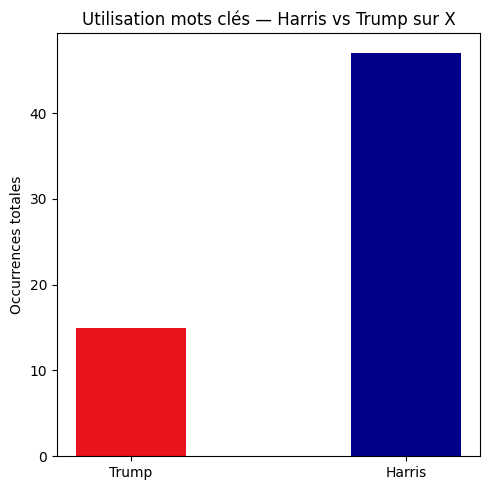

In [32]:
total_x     = sum(keyword_trump_x.values())
total_truth = sum(keyword_harris_x_2.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Trump', 'Harris'], [total_x, total_truth],
       color=['#E9141D', 'darkblue'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Utilisation mots clés — Harris vs Trump sur X')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

### Comparaison de l'utilisation de mots-clés chez Trump et Harris sur X et Truth Social #1

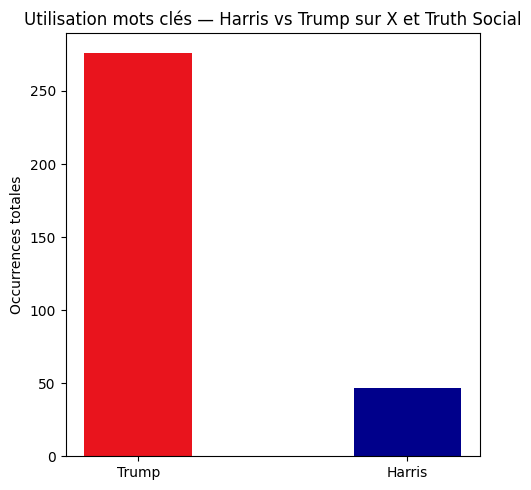

In [ ]:
total_x     = sum(keyword_trump_x.values()) + sum(keyword_trump_truth.values()) 
total_truth = sum(keyword_harris_x_2.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Trump (immigration related)', 'Harris'], [total_x, total_truth],
       color=['#E9141D', 'darkblue'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Utilisation mots clés — Harris vs Trump sur X et Truth Social')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

## Plot expressions de campagne

### Comparaison de l'utilisation d'expressions de campagne chez Trump et Harris sur X (Twitter) #1

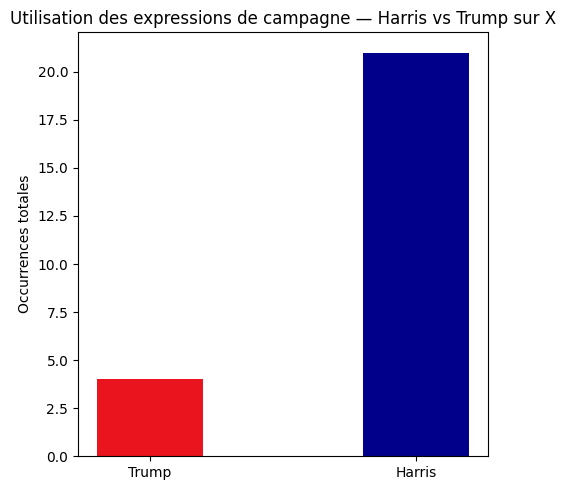

In [31]:
total_trump_x = sum(expr_trump_x.values())
total_harris_x_2 = sum(expr_harris_x_2.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Trump', 'Harris'], [total_trump_x, total_harris_x_2],
       color=['#E9141D', 'darkblue'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Utilisation des expressions de campagne — Harris vs Trump sur X')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

### Comparaison de l'utilisation d'expressions de campagne chez Trump et Harris sur X (Twitter) et Truth Social #1

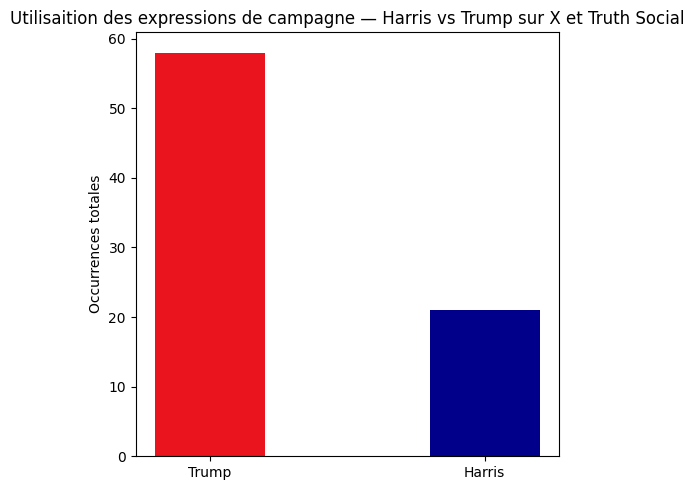

In [28]:
total_x_truth = sum(expr_trump_x.values()) + sum(expr_trump_truth.values())
total_truth = sum(expr_harris_x_2.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Trump', 'Harris'], [total_x_truth, total_truth],
       color=['#E9141D', 'darkblue'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Utilisaition des expressions de campagne — Harris vs Trump sur X et Truth Social')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

### Comparaison de l'utilisation d'expressions de campagne chez Trump et Harris sur X (Twitter) #2

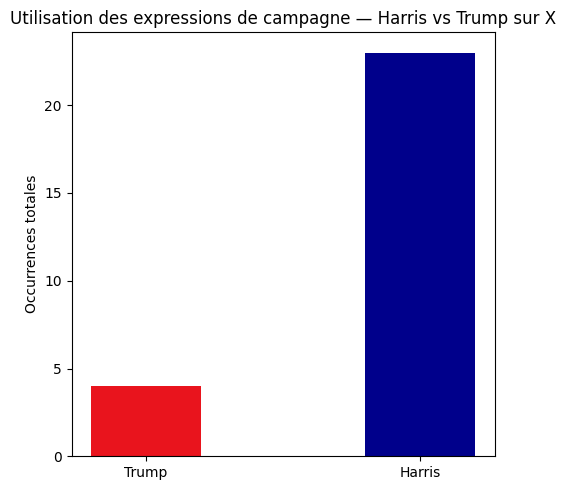

In [35]:
total_trump_x = sum(expr_trump_x.values())
total_harris_x_2 = sum(expr_harris_x_3.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Trump', 'Harris'], [total_trump_x, total_harris_x_2],
       color=['#E9141D', 'darkblue'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Utilisation des expressions de campagne — Harris vs Trump sur X')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

### Comparaison de l'utilisation d'expressions de campagne chez Trump et Harris sur X (Twitter) et Truth Social #2

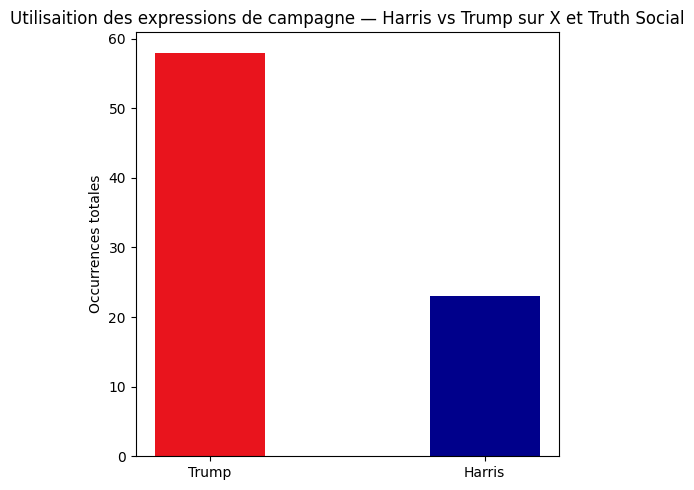

In [36]:
total_x_truth = sum(expr_trump_x.values()) + sum(expr_trump_truth.values())
total_truth = sum(expr_harris_x_3.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Trump', 'Harris'], [total_x_truth, total_truth],
       color=['#E9141D', 'darkblue'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Utilisaition des expressions de campagne — Harris vs Trump sur X et Truth Social')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

## Plot Name_Drop

### Harris

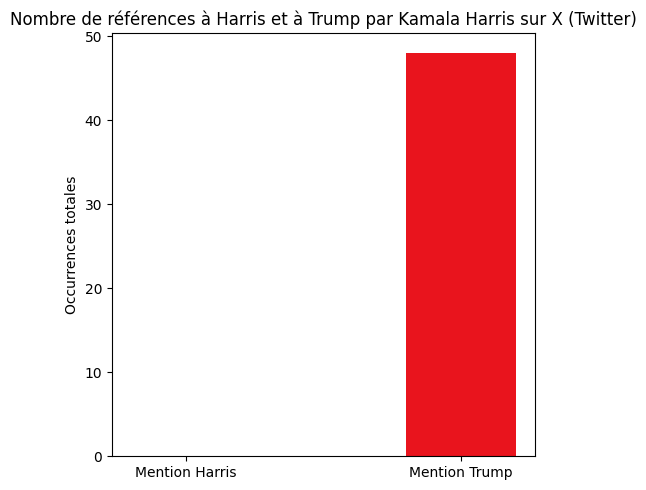

In [43]:
harris_drop = sum(counter_name_2.values())
trump_drop = sum(counter_name.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Mention Harris', 'Mention Trump'], [harris_drop, trump_drop],
       color=['darkblue', '#E9141D'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Nombre de références à Harris et à Trump par Kamala Harris sur X (Twitter)')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

### Trump

#### Sur X (Twitter)

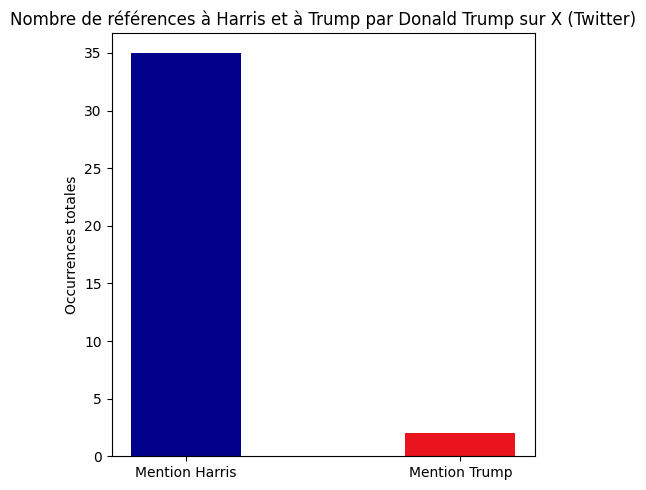

In [46]:
harris_drop = sum(counter_name_3.values())
trump_drop = sum(counter_name_6.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Mention Harris', 'Mention Trump'], [harris_drop, trump_drop],
       color=['darkblue', '#E9141D'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Nombre de références à Harris et à Trump par Donald Trump sur X (Twitter)')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

#### Sur Truth_Social

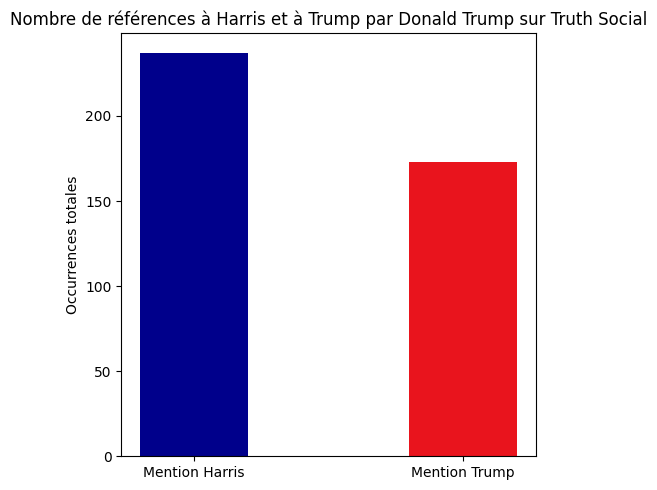

In [66]:
harris_drop = sum(counter_name_4.values())
trump_drop = sum(counter_name_5.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Mention Harris', 'Mention Trump'], [harris_drop, trump_drop],
       color=['darkblue', '#E9141D'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Nombre de références à Harris et à Trump par Donald Trump sur Truth Social')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

### Sur X + Truth Social

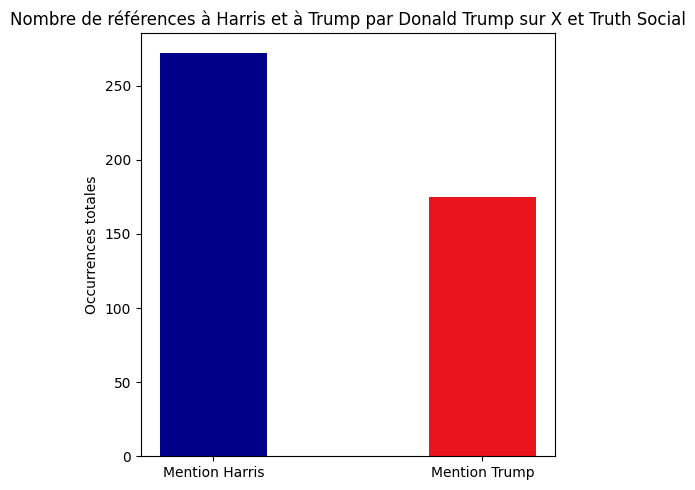

In [67]:
harris_drop = sum(counter_name_4.values()) + sum(counter_name_3.values())
trump_drop = sum(counter_name_5.values()) + sum(counter_name_6.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Mention Harris', 'Mention Trump'], [harris_drop, trump_drop],
       color=['darkblue', '#E9141D'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Nombre de références à Harris et à Trump par Donald Trump sur X et Truth Social')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

### Tous réseaux confondus

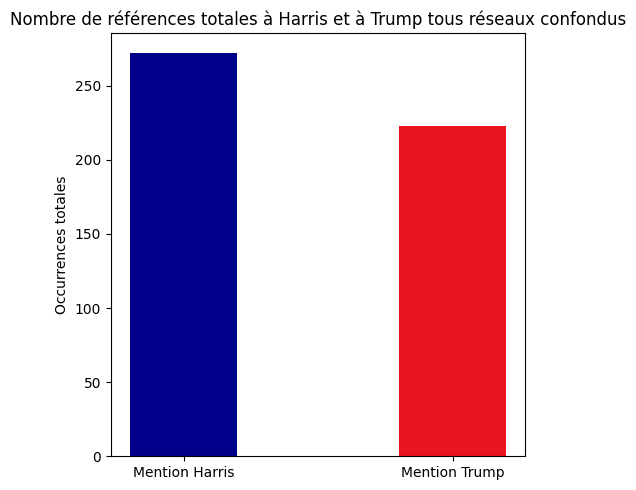

In [70]:
harris_drop = sum(counter_name_4.values()) + sum(counter_name_3.values()) + sum(counter_name_2.values())
trump_drop = sum(counter_name_5.values()) + sum(counter_name_6.values()) + sum(counter_name.values())

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(['Mention Harris', 'Mention Trump'], [harris_drop, trump_drop],
       color=['darkblue', '#E9141D'], width=0.4)

ax.set_ylabel('Occurrences totales')
ax.set_title('Nombre de références totales à Harris et à Trump tous réseaux confondus')

plt.tight_layout()
plt.savefig('counter_total.png', dpi=150)
plt.show()

## Plot We_Counter

### Harris

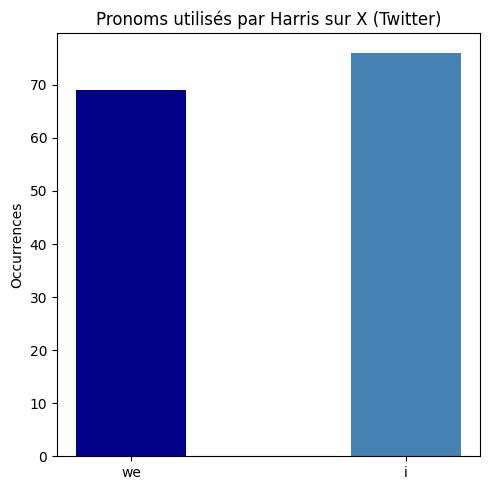

In [56]:
colors = ['darkblue', 'steelblue']

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(h_counter.keys(), h_counter.values(), color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title('Pronoms utilisés par Harris sur X (Twitter)')

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

### Trump

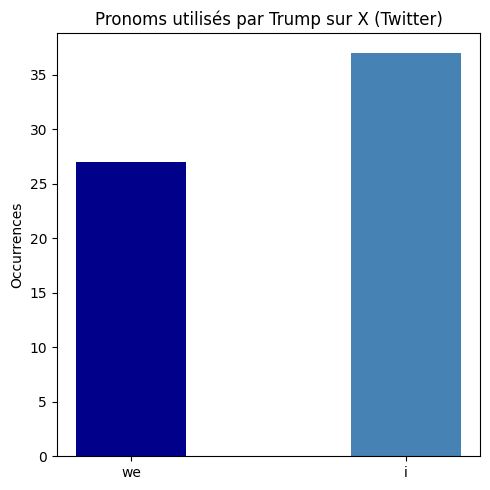

In [26]:
colors = ['darkblue', 'steelblue']

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(t_x_counter.keys(), t_x_counter.values(), color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title('Pronoms utilisés par Trump sur X (Twitter)')

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

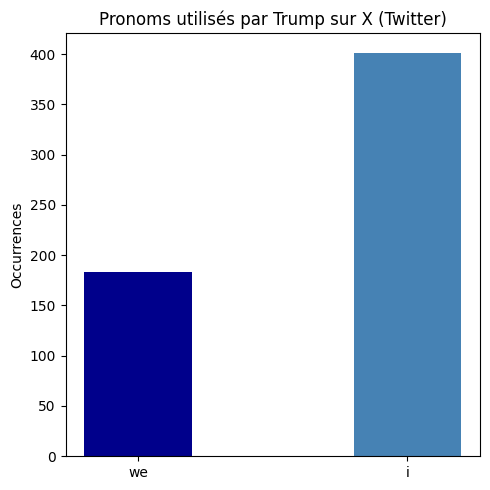

In [28]:
olors = ['darkblue', 'steelblue']

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(t_truth_counter.keys(), t_truth_counter.values(), color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title('Pronoms utilisés par Trump sur X (Twitter)')

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

### Trump vs Harris - X - "i"

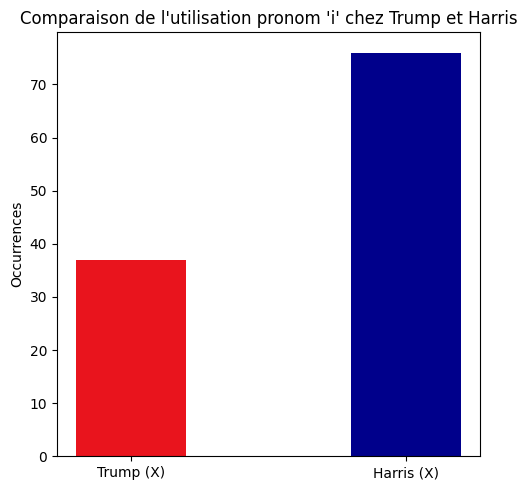

In [65]:
colors = ['#E9141D', 'darkblue']

fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Trump (X)', 'Harris (X)']
values = [t_x_counter["i"], h_counter["i"]]

ax.bar(labels, values, color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title("Comparaison de l'utilisation pronom 'i' chez Trump et Harris")

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

### Trump vs Harris - X - "we"

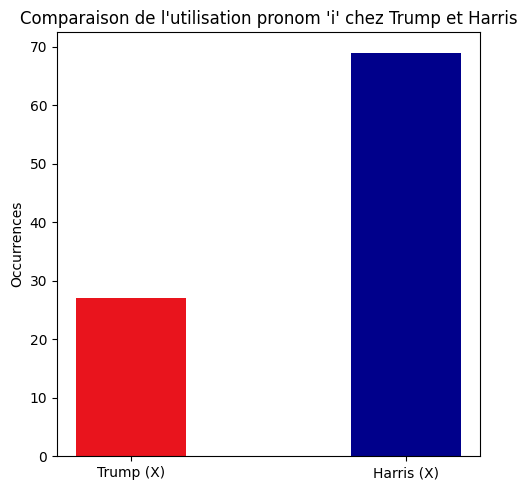

In [64]:
colors = ['#E9141D', 'darkblue']

fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Trump (X)', 'Harris (X)']
values = [t_x_counter["we"], h_counter["we"]]

ax.bar(labels, values, color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title("Comparaison de l'utilisation pronom 'i' chez Trump et Harris")

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

### Trump vs Harris - Truth Social vs X - "i"

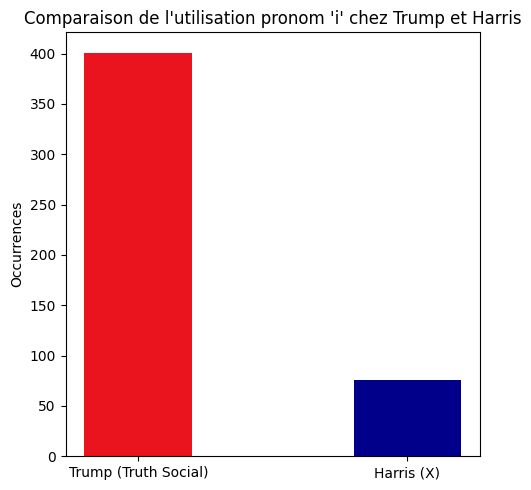

In [57]:
colors = ['#E9141D', 'darkblue']

fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Trump (Truth Social)', 'Harris (X)']
values = [t_truth_counter["i"], h_counter["i"]]

ax.bar(labels, values, color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title("Comparaison de l'utilisation pronom 'i' chez Trump et Harris")

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

### Trump vs Harris - Truth Social vs X - "we"

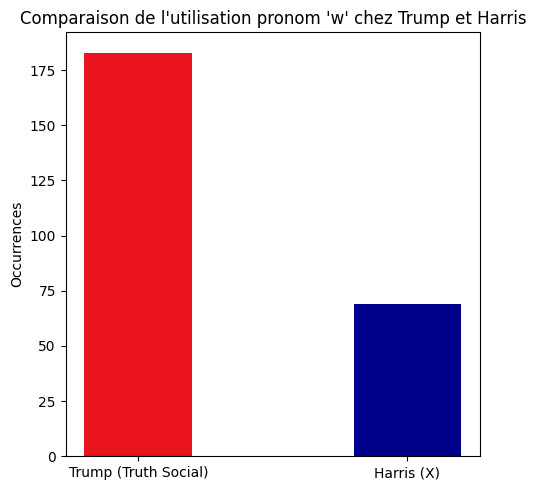

In [56]:
colors = ['#E9141D', 'darkblue']

fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Trump (Truth Social)', 'Harris (X)']
values = [t_truth_counter["we"], h_counter["we"]]

ax.bar(labels, values, color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title("Comparaison de l'utilisation pronom 'w' chez Trump et Harris")

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

### Trump vs Harris - Truth Social + X - "i"

In [34]:
trump_total_counter = sum(t_x_counter.values()) + sum(t_truth_counter.values())

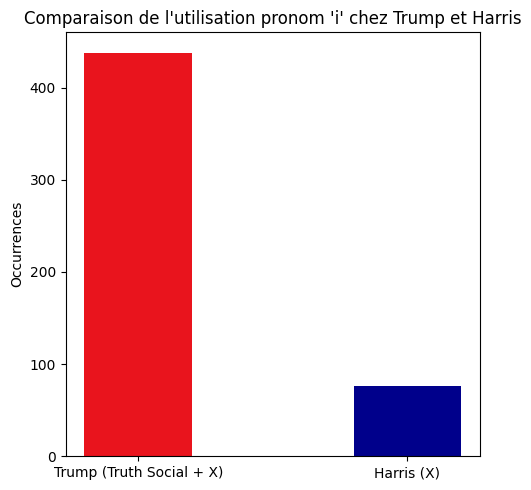

In [63]:
colors = ['#E9141D', 'darkblue']

fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Trump (Truth Social + X)', 'Harris (X)']
values = [t_x_counter["i"] + t_truth_counter["i"], h_counter["i"]]

ax.bar(labels, values, color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title("Comparaison de l'utilisation pronom 'i' chez Trump et Harris")

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

### Trump vs Harris - Truth Social + X - "we"

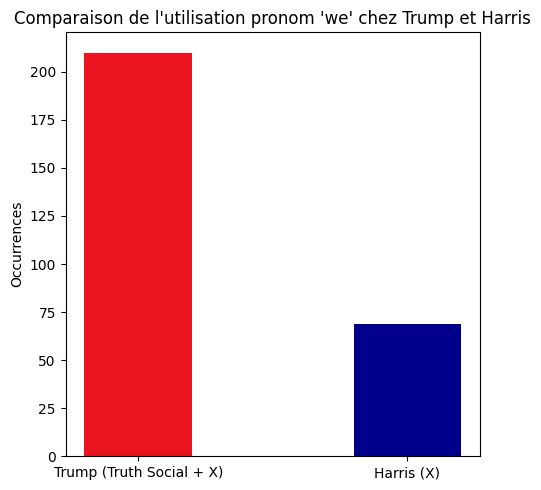

In [58]:
colors = ['#E9141D', 'darkblue']

fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Trump (Truth Social + X)', 'Harris (X)']
values = [t_x_counter["we"] + t_truth_counter["we"], h_counter["we"]]

ax.bar(labels, values, color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title("Comparaison de l'utilisation pronom 'we' chez Trump et Harris")

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150)
plt.show()

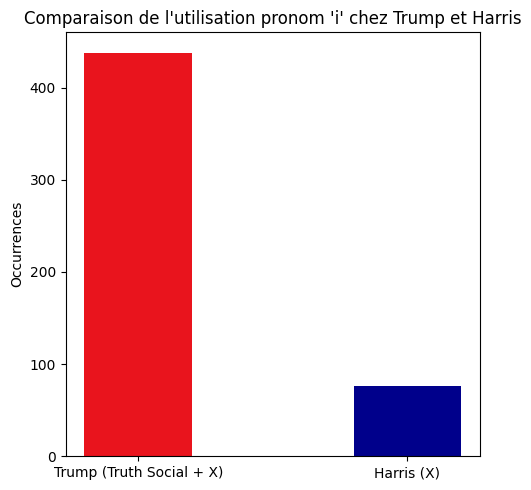

In [61]:
colors = ['#E9141D', 'darkblue']

fig, ax = plt.subplots(figsize=(5, 5))

labels = ['Trump (Truth Social + X)', 'Harris (X)']
values = [t_truth_counter["i"] + t_x_counter["i"] , h_counter["i"]]

ax.bar(labels, values, color=colors, width=0.4)

ax.set_ylabel('Occurrences')
ax.set_title("Comparaison de l'utilisation pronom 'i' chez Trump et Harris")

plt.tight_layout()
plt.savefig('harris_pronouns.png', dpi=150) 
plt.show() 